# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

c:\projects\DL_RusyaevaSP_6401\lab1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



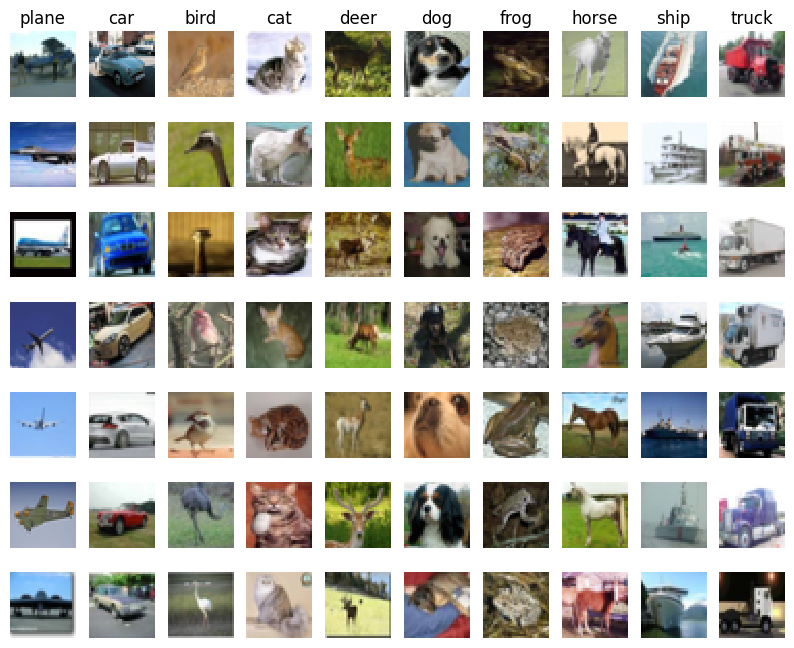

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7 # Сколько картинок каждого класса показать

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    # Выбираем случайные картинки (7 штук) для каждого класса
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
# Врзьмем 5000 для обучения и 500 для теста тк kNN медленный
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
# Считаем расстояния
dists_no_loops = classifier.compute_distances_no_loops(X_test)
# Предсказываем метки для k=1
y_test_pred = classifier.predict_labels(dists_no_loops, k=1)

dists_one_loop = classifier.compute_distances_one_loop(X_test)
y_test_pred_one_loop = classifier.predict_labels(dists_one_loop, k=1)

dists_two_loops = classifier.compute_distances_two_loops(X_test)
y_test_pred_two_loops = classifier.predict_labels(dists_two_loops, k=1)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


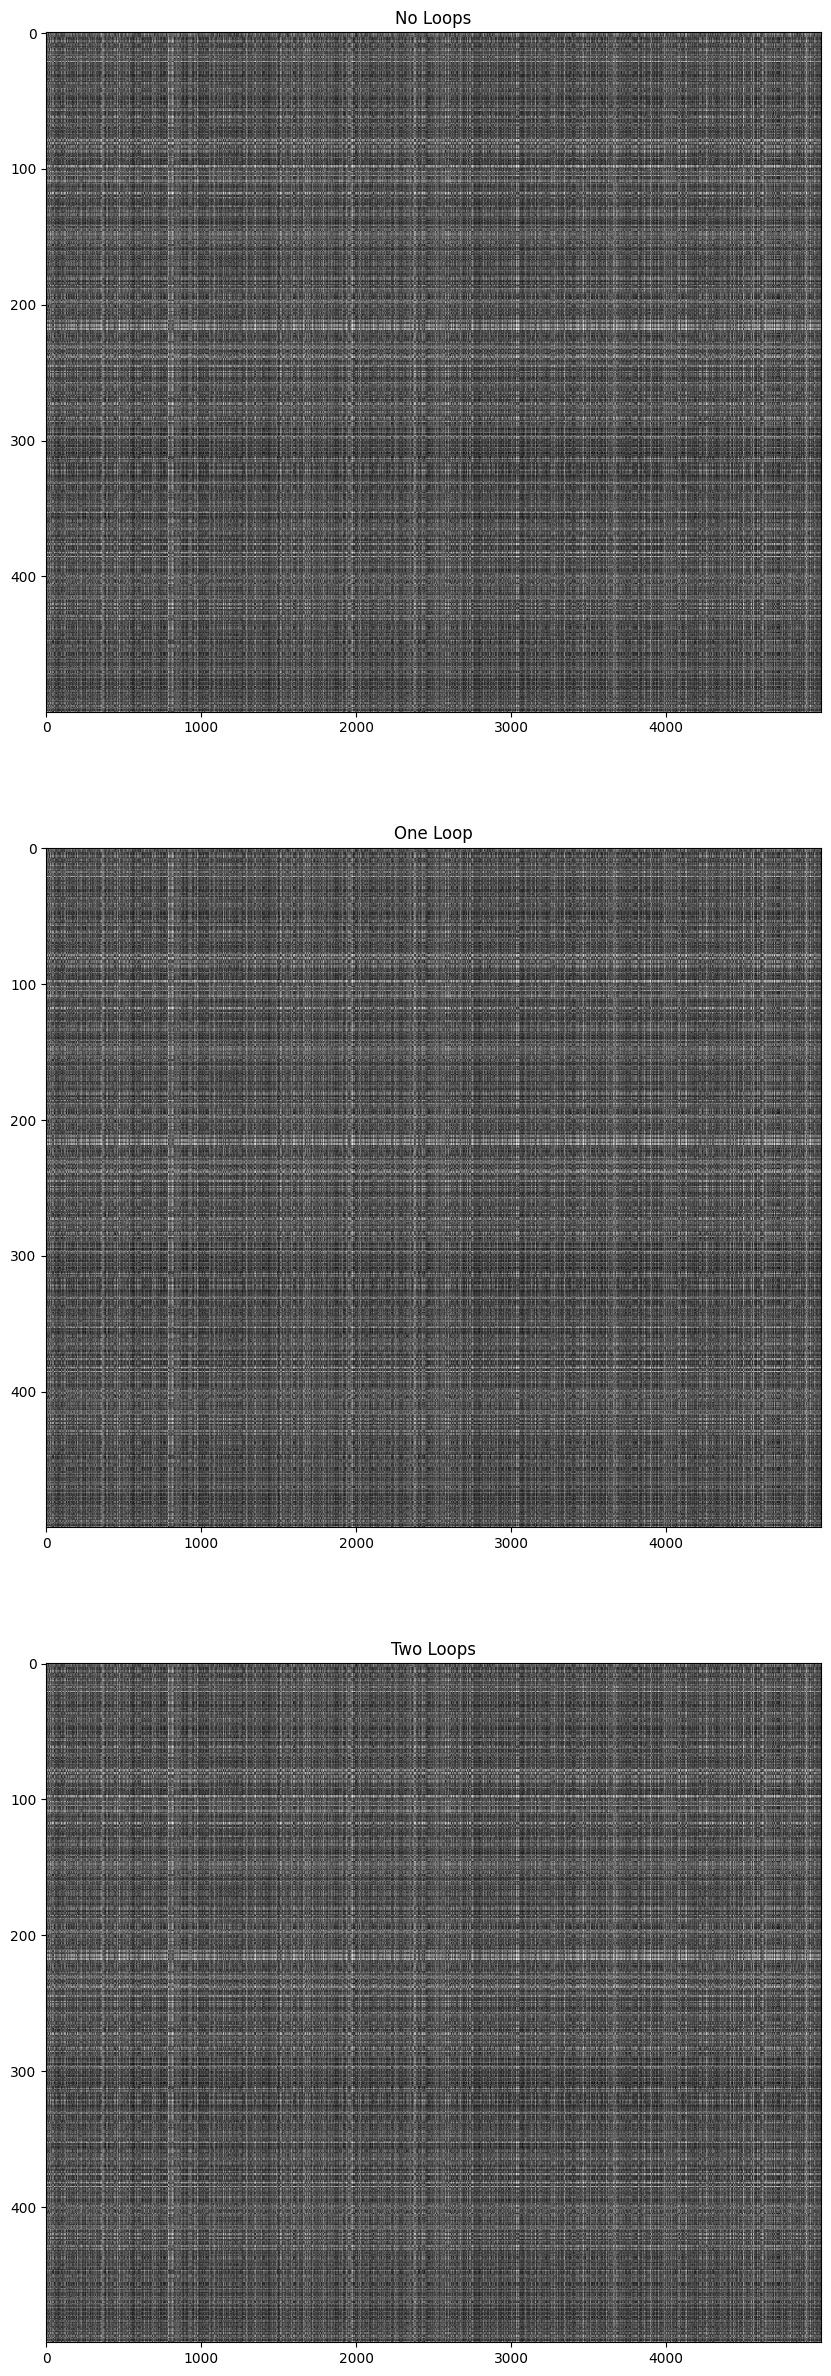

In [17]:
plt.figure(figsize=(10, 30)) 

plt.subplot(3, 1, 1)
plt.imshow(dists_no_loops, interpolation='none', aspect='auto')
plt.title('No Loops')

plt.subplot(3, 1, 2)
plt.imshow(dists_one_loop, interpolation='none', aspect='auto')
plt.title('One Loop')

plt.subplot(3, 1, 3)
plt.imshow(dists_two_loops, interpolation='none', aspect='auto')
plt.title('Two Loops')

plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [15]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('%d/%d correct, accuracy = %f' % (num_correct, num_test, accuracy))

137/500 correct, accuracy = 0.274000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1, accuracy = 0.274
k = 3, accuracy = 0.272
k = 5, accuracy = 0.278
k = 7, accuracy = 0.274
k = 10, accuracy = 0.282
k = 12, accuracy = 0.256
k = 15, accuracy = 0.272
k = 20, accuracy = 0.272
k = 50, accuracy = 0.252
k = 100, accuracy = 0.222


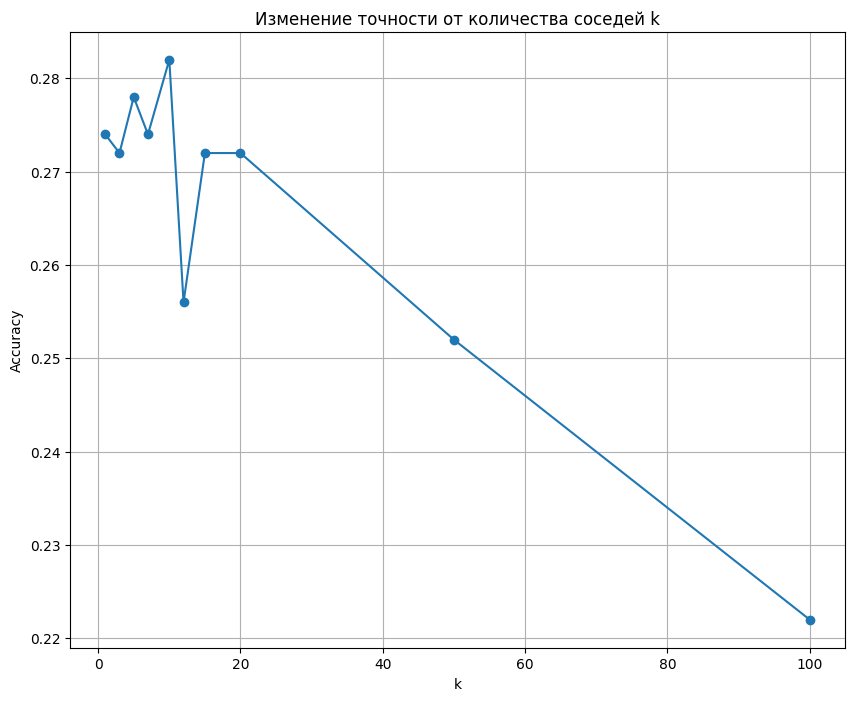

In [16]:
k_choices = [1, 3, 5, 7, 10, 12, 15, 20, 50, 100]
accuracies = []

for k in k_choices:
    y_test_pred = classifier.predict_labels(dists_no_loops, k=k)
    num_correct = np.sum(y_test_pred == y_test)
    accuracy = float(num_correct) / num_test
    accuracies.append(accuracy)
    print(f'k = {k}, accuracy = {accuracy}')

plt.plot(k_choices, accuracies, marker='o')
plt.title('Изменение точности от количества соседей k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [30]:
num_folds = 5
k_choices = [1, 3, 5, 7, 10, 12, 15, 20, 50, 100]

# Разбиваем данные на фолды
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for i in range(num_folds):
        # i фолд для теста, остальные для обучения
        X_train_cv = np.concatenate([X_train_folds[j] for j in range(num_folds) if j != i])
        y_train_cv = np.concatenate([y_train_folds[j] for j in range(num_folds) if j != i])
        X_val_cv = X_train_folds[i]
        y_val_cv = y_train_folds[i]

        # Обучаем и предсказываем
        classifier.train(X_train_cv, y_train_cv)
        dists_cv = classifier.compute_distances_no_loops(X_val_cv)
        y_val_pred = classifier.predict_labels(dists_cv, k=k)

        # Точность
        accuracy = np.mean(y_val_pred == y_val_cv)
        k_to_accuracies[k].append(accuracy)

# Среднее для каждого k
k_avg = {}
for k, accs in k_to_accuracies.items():
    k_avg[k] = np.mean(accs)
    print(f'k = {k}, accuracy = {k_avg[k]:.4f}')

# k с максимальной средней точностью
best_k = max(k_avg, key=k_avg.get)
print(f'\nЛчушее k = {best_k}, accuracy = {k_avg[best_k]:.4f}')

k = 1, accuracy = 0.2656
k = 3, accuracy = 0.2496
k = 5, accuracy = 0.2732
k = 7, accuracy = 0.2744
k = 10, accuracy = 0.2802
k = 12, accuracy = 0.2794
k = 15, accuracy = 0.2750
k = 20, accuracy = 0.2790
k = 50, accuracy = 0.2744
k = 100, accuracy = 0.2616

Лчушее k = 10, accuracy = 0.2802



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [31]:
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('accuracy = %f' % accuracy)

accuracy = 0.282000


1.11 Сделайте выводы по результатам 1 части задания.

Метод kNN показалточность около 28%. Это лучше чем случайное угадывание (10%), но все еще довольно низкое знаечние для классификации сложных изображений.

При k=1 модель была более чувствительна к шуму. С помощью кросс-валидации было найдено лучшее k=10, которое позволило немного повысить точность.

Главный недостаток данного метода - его медленная скорость работы на этапе предсказания. Алгоритм сравнивает каждый тестовый объект со всей обучающей выборкой. Векторизация (compute_distances_no_loops) в данном случае крайне важна для ускорения работы с большими данными.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [32]:
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Валидационная выборка
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Обучающая выборка
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Тестовая выборка
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

# Dev-выборка
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Преобразование в одномерный массив
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)
Dev data shape:  (500, 3072)
Dev labels shape:  (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


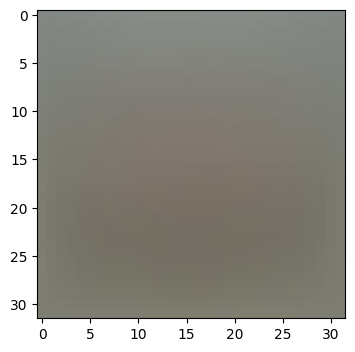

(49000, 3073) (1000, 3073) (1000, 3073)


In [33]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image


X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [34]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time


W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.463901



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [35]:
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -15.224768 analytic: -15.181695, relative error: 1.416580e-03
numerical: -12.644939 analytic: -12.644939, relative error: 1.196929e-11
numerical: -30.186843 analytic: -30.186843, relative error: 2.500282e-12
numerical: 12.399351 analytic: 12.399351, relative error: 1.362630e-11
numerical: -12.060345 analytic: -12.060345, relative error: 9.097603e-12
numerical: -16.742435 analytic: -16.742435, relative error: 2.923846e-11
numerical: 11.692847 analytic: 11.692847, relative error: 2.803606e-11
numerical: -21.705602 analytic: -21.705602, relative error: 4.254545e-12
numerical: -36.411007 analytic: -36.411007, relative error: 1.012217e-12
numerical: 5.649982 analytic: 5.649982, relative error: 1.979567e-11
numerical: -26.159420 analytic: -26.159420, relative error: 1.433836e-11
numerical: -17.780169 analytic: -17.780169, relative error: 1.460925e-11
numerical: -0.866940 analytic: -0.866940, relative error: 3.509740e-12
numerical: -5.660274 analytic: -5.660274, relative error: 4.8

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [36]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.041615s
Vectorized loss and gradient: computed in 0.001496s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [37]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 789.478837
iteration 100 / 1500: loss 287.472476
iteration 200 / 1500: loss 109.160501
iteration 300 / 1500: loss 42.055354
iteration 400 / 1500: loss 18.380963
iteration 500 / 1500: loss 10.030010
iteration 600 / 1500: loss 6.934817
iteration 700 / 1500: loss 6.270759
iteration 800 / 1500: loss 5.544229
iteration 900 / 1500: loss 5.696112
iteration 1000 / 1500: loss 6.007235
iteration 1100 / 1500: loss 5.349381
iteration 1200 / 1500: loss 5.395225
iteration 1300 / 1500: loss 4.762355
iteration 1400 / 1500: loss 5.595673
That took 3.038741s


In [38]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.374673
validation accuracy: 0.378000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [41]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

results = {}
best_val = -1
best_svm = None

for lr in learning_rates:
    for rs in regularization_strengths:
        svm = LinearSVM()
        svm.train(X_train, y_train, learning_rate=lr, reg=rs,
                  num_iters=1500, verbose=False)
        
        # Точность на обучающей выборке
        y_train_pred = svm.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        
        # точность на валидационной выборке
        y_val_pred = svm.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        
        # Сохраняем результаты
        results[(lr, rs)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (lr, reg, train_accuracy, val_accuracy))
    
print('Best accuracy: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.367878 val accuracy: 0.383000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.354918 val accuracy: 0.360000
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.053980 val accuracy: 0.052000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.100265 val accuracy: 0.087000
Best accuracy: 0.383000


2.9 Сделайте выводы по второй части задания

Линейный SVM показал точность 38%, что значительно выше метода kNN. При этом SVM работает гораздо быстрее на этапе предсказания.

Кросс-валидация показала, что модель крайне чувствительна к значению скорости обучения. При высоком learning_rate произошло резкое падение точности до уровня случайного угадывания (менее 10%). L2 регуляризация помогает контролировать веса и предотвращать переобучение.

Несмотря на улучшение по сравнению с kNN, точность в 38% все еще недостаточна для практического применения. Линейная модель не способна уловить сложные нелинейные зависимости в изображениях.